In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("C:\\Users\\Y.PHANI MANJUNATH\\Downloads\\Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.columns.tolist()

['Restaurant ID',
 'Restaurant Name',
 'Country Code',
 'City',
 'Address',
 'Locality',
 'Locality Verbose',
 'Longitude',
 'Latitude',
 'Cuisines',
 'Average Cost for two',
 'Currency',
 'Has Table booking',
 'Has Online delivery',
 'Is delivering now',
 'Switch to order menu',
 'Price range',
 'Aggregate rating',
 'Rating color',
 'Rating text',
 'Votes']

In [5]:
df[['Longitude','Latitude']]

,Longitude,Latitude
0,121.027535,14.565443
1,121.014101,14.553708
2,121.056831,14.581404
3,121.056475,14.585318
4,121.057508,14.584450
...,...,...
9546,28.977392,41.022793
9547,29.041297,41.009847
9548,29.034640,41.055817
9549,29.036019,41.057979


In [7]:
import matplotlib.pyplot as plt

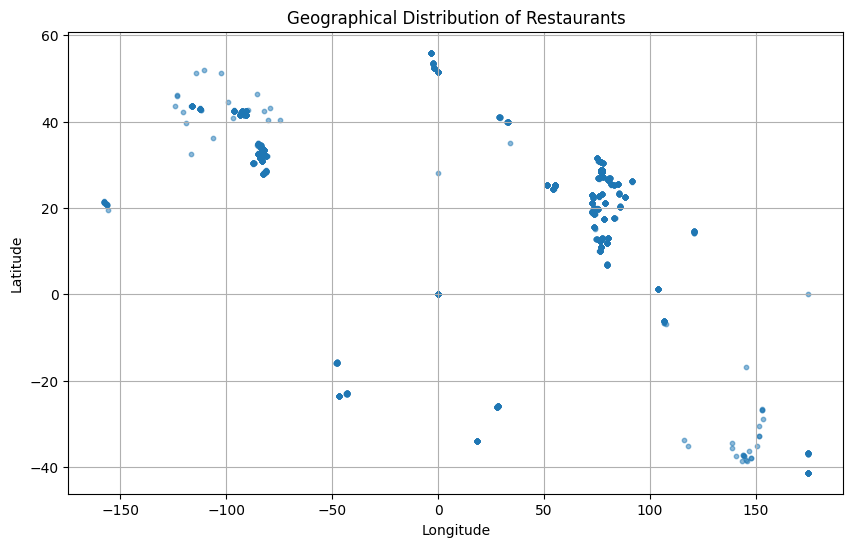

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.5, s=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Restaurants')
plt.grid(True)
plt.show()


In [12]:
city_counts = df.groupby('City')['Restaurant ID'].count().sort_values(ascending=False)

In [14]:
city_counts.head(20)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Ahmedabad         21
Amritsar          21
Abu Dhabi         20
Albany            20
Agra              20
Savannah          20
Surat             20
Augusta           20
Aurangabad        20
Auckland          20
Athens            20
Ankara            20
Name: Restaurant ID, dtype: int64

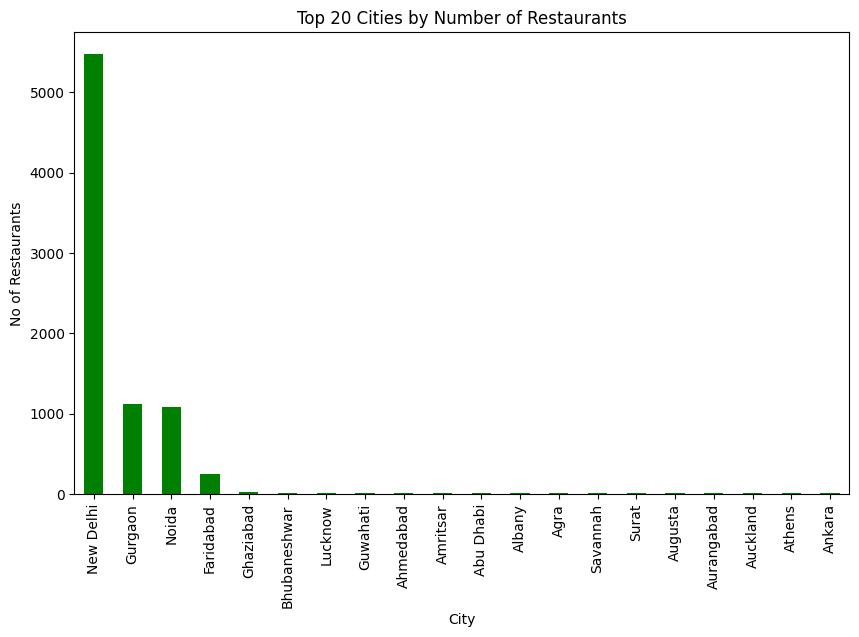

In [31]:
plt.figure(figsize=(10,6))
city_counts.head(20).plot(kind='bar',color="g")
plt.xlabel('City')
plt.ylabel('No of Restaurants')
plt.title('Top 20 Cities by Number of Restaurants')
plt.show()

In [18]:
average_rating_city=df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

In [20]:
print("average_rating_city\n",average_rating_city)

average_rating_city
 City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


In [22]:
avg_rating_locality = df.groupby(['City', 'Locality'])['Aggregate rating'].mean().sort_values(ascending=False)
print("Average rating by city and locality:\n", avg_rating_locality.head())

Average rating by city and locality:
 City        Locality                                   
Pasay City  Sofitel Philippine Plaza Manila, Pasay City    4.9
Pretoria    West Park                                      4.9
Orlando     The Milk District                              4.9
            Windermere                                     4.9
Tangerang   Pondok Aren                                    4.9
Name: Aggregate rating, dtype: float64


In [27]:
unique_cuisines_city = df.groupby('City')['Cuisines'].nunique().sort_values(ascending=False)
print("Number of unique cuisines by city:\n", unique_cuisines_city.head(10))

Number of unique cuisines by city:
 City
New Delhi     892
Gurgaon       362
Noida         248
Faridabad      87
Ahmedabad      21
Cape Town      20
Coimbatore     20
Lucknow        20
Colombo        20
Sharjah        20
Name: Cuisines, dtype: int64


In [29]:
average_price_range=df.groupby('City')['Price range'].mean().sort_values(ascending=False)
print("Average Price Range by the city:\n",average_price_range)
                                                                        

Average Price Range by the city:
 City
Panchkula           4.0
Vineland Station    4.0
Paynesville         4.0
Johannesburg        4.0
Inner City          4.0
                   ... 
Fernley             1.0
Dicky Beach         1.0
Miller              1.0
Mc Millan           1.0
Vernonia            1.0
Name: Price range, Length: 141, dtype: float64


In [30]:
average_cost_for_two_city=df.groupby('City')['Average Cost for two'].mean().sort_values(ascending=False)
print("Average Cost for Two by City:\n",average_cost_for_two_city)

Average Cost for Two by City:
 City
Jakarta           308437.500000
Tangerang         250000.000000
Bogor             160000.000000
Bandung           150000.000000
Pasay City          3333.333333
                      ...      
Lakeview              10.000000
Lakes Entrance         7.000000
Inverloch              7.000000
Dicky Beach            7.000000
Miller                 0.000000
Name: Average Cost for two, Length: 141, dtype: float64


In [32]:
%history -f internshipTASK4.py